# SAC training on ImprovedB747Env (b747improved)

Этот ноутбук обучает **Soft Actor-Critic (SAC)** на среде `tensoraerospace.envs.b747.ImprovedB747Env` по JSON-конфигу:

- `example/reinforcement_learning/configs/sac_b747improved.json`

Логи TensorBoard пишутся в `runs/`.

> Если `import torch` падает — установи PyTorch по инструкции с `https://pytorch.org/get-started/locally/` и перезапусти ядро.


In [1]:
import datetime as dt
from typing import Any

import numpy as np

try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "PyTorch is required to run this notebook.\n"
        "Install it first (see https://pytorch.org/get-started/locally/), then restart the kernel."
    ) from exc

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent.sac.sac import SAC


2026-01-03 18:14:14.446729: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-03 18:14:14.446762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-03 18:14:14.447592: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-03 18:14:14.452842: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-03 18:14:15.197612: W tensorflow/compiler/tf2

In [2]:
# User controls (override here instead of editing code below)
# Env params
DT = 0.1
REWARD_MODE = "tracking"  # or "step_response"
INITIAL_STATE = [0.0, 0.0, 0.0, 0.0]
# reference_signal shape: (1, N)
REFERENCE_SIGNAL = [[
    0.0, 0.0005482211664640374, 0.0010959013048243186, 0.0016424999209065062,
    0.0021874775878681775, 0.0027302964785479926, 0.003270420896236169,
    0.003807317803342461, 0.004340457347439902, 0.004869313384165187,
    0.005393363996459629, 0.0059120920096382935, 0.0064249855017789615,
    0.0069315383089272745, 0.007431250524619439, 0.007923628993229551,
    0.008408187796654669, 0.008884448733857301, 0.009351941792792112,
    0.009810205614251052, 0.010258787947169204, 0.010697246094941978,
    0.011125147352313219, 0.011542069432403042, 0.011947600883454014,
    0.01234134149488435, 0.012722902692247453, 0.013091907920707965,
    0.013447993016655935, 0.01379080656709234, 0.014120010256431278,
    0.014435279200376615, 0.01473630226654356, 0.01502278238150876,
    0.015294436823985909, 0.015550997503837517, 0.01579221122664752,
    0.016017839943593588, 0.016227660986372582, 0.01642146728694728,
    0.016599067581897532, 0.016760286601174172, 0.016904965241069367,
    0.01703296072123282, 0.017144146725578686, 0.017238413526944323,
    0.017315668095377754, 0.01737583418994699, 0.01741885243398063,
    0.017444680373665474, 0.017453292519943295, 0.017444680373665474,
    0.01741885243398063, 0.01737583418994699, 0.01731566809537775,
    0.017238413526944323, 0.017144146725578686, 0.017032960721232823,
    0.016904965241069367, 0.01676028660117417, 0.016599067581897536,
    0.01642146728694728, 0.01622766098637258, 0.016017839943593588,
    0.015792211226647517, 0.015550997503837517, 0.015294436823985905,
    0.01502278238150876, 0.014736302266543558, 0.014435279200376613,
    0.014120010256431278, 0.013790806567092338, 0.013447993016655935,
    0.013091907920707961, 0.012722902692247452, 0.012341341494884351,
    0.01194760088345401, 0.011542069432403042, 0.011125147352313215,
    0.010697246094941978, 0.010258787947169206, 0.009810205614251055,
    0.009351941792792104, 0.008884448733857297, 0.008408187796654667,
    0.007923628993229553, 0.007431250524619442, 0.0069315383089272676,
    0.006424985501778958, 0.005912092009638292, 0.005393363996459631,
    0.004869313384165192, 0.004340457347439895, 0.0038073178033424565,
    0.003270420896236168, 0.0027302964785479943, 0.0021874775878681745,
    0.0016424999209064988, 0.0010959013048243145, 0.0005482211664640366,
    2.1374118819130998e-18, -0.00054822116646404, -0.0010959013048243258,
    -0.0016424999209065099, -0.002187477587868178, -0.00273029647854799,
    -0.0032704208962361717, -0.003807317803342468, -0.0043404573474399065,
    -0.004869313384165187, -0.005393363996459627, -0.005912092009638294,
    -0.006424985501778968, -0.006931538308927277, -0.0074312505246194385,
    -0.00792362899322955, -0.008408187796654669, -0.008884448733857306,
    -0.009351941792792114, -0.009810205614251052, -0.010258787947169203,
    -0.01069724609494198, -0.011125147352313222, -0.011542069432403044,
    -0.011947600883454014, -0.01234134149488435, -0.012722902692247455,
    -0.013091907920707968, -0.013447993016655937, -0.01379080656709234,
    -0.014120010256431276, -0.01443527920037662, -0.014736302266543563,
    -0.015022782381508762, -0.015294436823985907, -0.015550997503837514,
    -0.015792211226647524, -0.016017839943593588, -0.016227660986372582,
    -0.01642146728694728, -0.016599067581897532, -0.016760286601174172,
    -0.01690496524106937, -0.017032960721232823, -0.017144146725578686,
    -0.017238413526944323, -0.017315668095377754, -0.01737583418994699,
    -0.01741885243398063, -0.017444680373665474, -0.017453292519943295,
    -0.017444680373665474, -0.01741885243398063, -0.01737583418994699,
    -0.017315668095377754, -0.017238413526944323, -0.017144146725578686,
    -0.01703296072123282, -0.016904965241069367, -0.01676028660117417,
    -0.016599067581897536, -0.016421467286947277, -0.016227660986372586,
    -0.016017839943593588, -0.01579221122664751, -0.015550997503837517,
    -0.015294436823985904, -0.015022782381508766, -0.014736302266543558,
    -0.014435279200376605, -0.01412001025643128, -0.013790806567092334,
    -0.01344799301665594, -0.013091907920707963, -0.012722902692247441,
    -0.012341341494884353, -0.011947600883454005, -0.011542069432403048,
    -0.011125147352313217, -0.010697246094941966, -0.010258787947169208,
    -0.009810205614251047, -0.00935194179279212, -0.0088844487338573,
    -0.008408187796654655, -0.007923628993229554, -0.007431250524619431,
    -0.006931538308927284, -0.00642498550177896, -0.005912092009638279,
    -0.0053933639964596335, -0.004869313384165178, -0.004340457347439897,
    -0.0038073178033424587, -0.003270420896236155, -0.002730296478547997,
    -0.0021874775878681692, -0.001642499920906501, -0.0010959013048243166,
    -0.0005482211664640232, -4.2748237638261996e-18
]]

# Training params
EPISODES = 1200
SEED = 42
SAVE_BEST = True
SAVE_GRADIENTS = False
SAVE_FINAL = True

# SAC hyperparameters (tuned for ImprovedB747Env tracking / control)
# Notes:
# - tau=0.005 is standard (0.02 is usually too aggressive)
# - start alpha at 0.2 and let auto-entropy tune it (we also fixed warm-start in SAC)
# - log_every_updates reduces TensorBoard overhead
SAC_PARAMS = {
    "gamma": 0.99,
    "tau": 0.005,
    "alpha": 0.2,
    "verbose_histogram": False,
    "memory_capacity": 300000,
    "policy_type": "Gaussian",
    "updates_per_step": 1,
    "target_update_interval": 1,
    "batch_size": 256,
    "automatic_entropy_tuning": True,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "lr": 3e-4,
    "policy_lr": 3e-4,
    "log_every_updates": 200,
}


# Derived
NUMBER_TIME_STEPS = 201

DT, REWARD_MODE, NUMBER_TIME_STEPS

(0.1, 'tracking', 201)

In [3]:
# Derived shapes
REFERENCE_SIGNAL_NP = np.asarray(REFERENCE_SIGNAL, dtype=np.float64).reshape(1, -1)
NUMBER_TIME_STEPS = int(NUMBER_TIME_STEPS or REFERENCE_SIGNAL_NP.shape[1])
INITIAL_STATE_NP = np.asarray(INITIAL_STATE, dtype=np.float32).reshape(-1)

NUMBER_TIME_STEPS


201

In [4]:
# Set seeds
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Run directories


In [5]:
# Build environment
env = ImprovedB747Env(
    initial_state=INITIAL_STATE,
    reference_signal=REFERENCE_SIGNAL,
    number_time_steps=NUMBER_TIME_STEPS,
    dt=DT,
    reward_mode=REWARD_MODE,
    initial_elevator_deg=0.0,
)

try:
    env.unwrapped.model.discretisation_time = float(DT)
except Exception:
    pass

print("Env: ImprovedB747Env")
print("  dt:", getattr(env, "dt", None))
print("  reward_mode:", getattr(env, "reward_mode", None))
print("  number_time_steps:", getattr(env, "number_time_steps", None))
print("  obs_space:", getattr(env, "observation_space", None))
print("  act_space:", getattr(env, "action_space", None))


Env: ImprovedB747Env
  dt: 0.1
  reward_mode: tracking
  number_time_steps: 201
  obs_space: Box(-1.0, 1.0, (4,), float32)
  act_space: Box(-1.0, 1.0, (1,), float32)


In [6]:
# Build agent (SAC)
policy_params = dict(SAC_PARAMS)

# If only lr provided, mirror to policy_lr (SAC supports both)
if "policy_lr" not in policy_params and "lr" in policy_params:
    policy_params["policy_lr"] = policy_params["lr"]

agent_kwargs: dict[str, Any] = {"env": env, **policy_params, "seed": SEED}
agent = SAC(**agent_kwargs)

print("Agent: SAC")
print("  device:", getattr(agent, "device", None))
SAC_PARAMS


Agent: SAC
  device: cuda


{'gamma': 0.99,
 'tau': 0.005,
 'alpha': 0.2,
 'verbose_histogram': False,
 'memory_capacity': 300000,
 'policy_type': 'Gaussian',
 'updates_per_step': 1,
 'target_update_interval': 1,
 'batch_size': 256,
 'automatic_entropy_tuning': True,
 'device': 'cuda',
 'lr': 0.0003,
 'policy_lr': 0.0003,
 'log_every_updates': 200}

In [7]:
# Train
# Tip: for step-response benchmarking switch REWARD_MODE="step_response" and use a step reference.

train_interrupted = False
save_root = f"runs/sac_b747improved_{dt.datetime.now().strftime('%Y%m%d_%H%M%S')}"

try:
    agent.train(
        num_episodes=int(EPISODES),
        save_best=bool(SAVE_BEST),
        save_path=str(save_root),
        save_best_with_gradients=bool(SAVE_GRADIENTS),
    )
except KeyboardInterrupt:
    train_interrupted = True
    print("\nInterrupted by user (KeyboardInterrupt).")
finally:
    if bool(SAVE_FINAL):
        agent.save(path=str(save_root + "_final"), save_gradients=bool(SAVE_GRADIENTS))

print("TensorBoard log_dir:", agent.log_dir)
print("Saved to:", save_root)
print("Training interrupted:" if train_interrupted else "Training completed.")


100%|██████████| 1200/1200 [50:24<00:00,  2.52s/it]

TensorBoard log_dir: None
Saved to: runs/sac_b747improved_20260103_055102
Training completed.


Eval ep 1: return=-0.187, steps=199
Eval ep 2: return=-0.187, steps=199
Eval ep 3: return=-0.187, steps=199


<Figure size 1200x400 with 0 Axes>

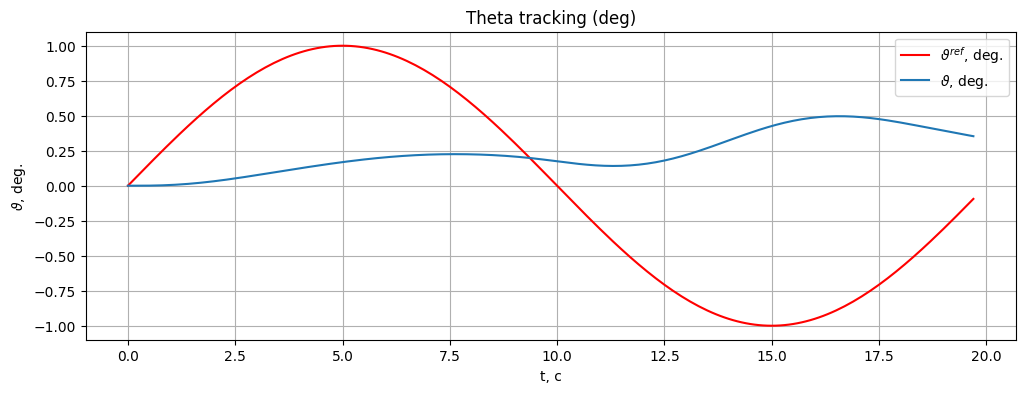


Mean eval return over 3 episodes: -0.187


In [7]:
# Quick evaluation (deterministic actions) + transient plot (theta tracking)
EVAL_EPISODES = 3

def evaluate_episode(agent, env):
    obs, _info = env.reset()
    done = False
    total = 0.0
    steps = 0
    while not done:
        action = agent.select_action(obs, evaluate=True)
        obs, reward, terminated, truncated, _info = env.step(action)
        done = bool(terminated or truncated)
        total += float(reward)
        steps += 1
    return total, steps

# Build a fresh eval env (so training env can keep its state if needed)
eval_env = ImprovedB747Env(
    initial_state=INITIAL_STATE,
    reference_signal=REFERENCE_SIGNAL*2,
    number_time_steps=NUMBER_TIME_STEPS,
    dt=DT,
    reward_mode=REWARD_MODE,
    initial_elevator_deg=0.0,
)
try:
    eval_env.unwrapped.model.discretisation_time = float(DT)
except Exception:
    pass

returns = []
try:
    for ep in range(EVAL_EPISODES):
        r, steps = evaluate_episode(agent, eval_env)
        returns.append(r)
        print(f"Eval ep {ep+1}: return={r:.3f}, steps={steps}")

    # Plot theta tracking (deg)
    import matplotlib.pyplot as plt

    t_sec = np.arange(NUMBER_TIME_STEPS) * DT
    plt.figure(figsize=(12, 4))
    eval_env.unwrapped.model.plot_transient_process(
        "theta",
        t_sec,
        np.asarray(REFERENCE_SIGNAL[0]*2, dtype=float),
        to_deg=True,
        figsize=(12, 4),
    )
    plt.title("Theta tracking (deg)")
    plt.show()
finally:
    try:
        eval_env.close()
    except Exception:
        pass

mean_r = float(np.mean(returns)) if returns else 0.0
print(f"\nMean eval return over {EVAL_EPISODES} episodes: {mean_r:.3f}")


In [8]:
# Optional: load an existing checkpoint to avoid retraining Phase 1
#
# Set BASE_RUN_DIR to one of the folders under `runs/` (created by the training cell).
# Then run this cell, skip the long training cell, and go straight to Phase 2 + step-eval.

from pathlib import Path

BASE_RUN_DIR = ""  # e.g. "runs/sac_b747improved_20260102_215916"
LOAD_GRADIENTS = False


def pick_latest_checkpoint_dir(run_dir: str) -> str:
    run = Path(run_dir)
    ckpt_root = run / "checkpoints"
    if not ckpt_root.exists():
        raise FileNotFoundError(f"checkpoints not found: {ckpt_root}")

    dirs = [p for p in ckpt_root.iterdir() if p.is_dir()]
    if not dirs:
        raise FileNotFoundError(f"No checkpoint dirs in: {ckpt_root}")

    dirs.sort(key=lambda p: p.stat().st_mtime)
    return str(dirs[-1])


if BASE_RUN_DIR:
    ckpt_dir = pick_latest_checkpoint_dir(BASE_RUN_DIR)
    print("Loading checkpoint:", ckpt_dir)
    agent = SAC.from_pretrained(ckpt_dir, load_gradients=bool(LOAD_GRADIENTS))
    print("Loaded agent. device:", getattr(agent, "device", None))



In [ ]:
# Phase 2 (fine-tune): step control curriculum on ImprovedB747Env
# Goal: good controller on a 1deg step at t=5s.
#
# Key trick: train on step references with reward_mode="tracking" first (dense signal),
# then fine-tune with reward_mode="step_response".

STEP_TIME_SEC = 5.0
STEP_TN_SEC = 20.0  # shorter horizon speeds training and focuses on transient
STEP_N_STEPS = int(STEP_TN_SEC / float(DT)) + 1

# Curriculum phases
STEP_PHASES = [
    {"name": "track_step_5deg", "reward_mode": "tracking", "step_deg": 5.0, "episodes": 600, "reset_replay": False},
    {"name": "track_step_1deg", "reward_mode": "tracking", "step_deg": 1.0, "episodes": 600, "reset_replay": False},
    # Reset replay before the strict objective to avoid mixing old targets/rewards
    {"name": "step_response_1deg", "reward_mode": "step_response", "step_deg": 1.0, "episodes": 1200, "reset_replay": True},
]

# Optional: wipe replay once before curriculum
# IMPORTANT: if you pre-trained on a *different* signal (e.g., sine), keep this TRUE.
RESET_REPLAY_AT_START = True

# Tracking phase SAC settings (dense reward -> learns correct sign/control quickly)
TRACK_ALPHA_INIT = 0.2
TRACK_UPDATES_PER_STEP = 1
TRACK_BATCH_SIZE = 256
TRACK_POLICY_LR = 3e-4
TRACK_CRITIC_LR = 3e-4
TRACK_LOG_EVERY_UPDATES = 500

# Step-response phase SAC settings
# - Treating time-limit as terminal (wrapper below) stabilizes Q-targets.
# - More updates per step helps critic fit the finite-horizon objective.
STEP_ALPHA = 0.12
STEP_UPDATES_PER_STEP = 4
STEP_BATCH_SIZE = 512
STEP_POLICY_LR = 1e-4
STEP_CRITIC_LR = 3e-4
STEP_LOG_EVERY_UPDATES = 500

# Eval target (fixed 1deg@5s)
STEP_EVAL_DEG = 1.0


def make_step_reference_signal(
    *, n_steps: int, dt: float, step_deg: float, step_time_sec: float
) -> list[list[float]]:
    t = np.arange(int(n_steps), dtype=np.float64) * float(dt)
    ref = np.zeros_like(t, dtype=np.float64)
    ref[t >= float(step_time_sec)] = np.deg2rad(float(step_deg))
    return ref.reshape(1, -1).tolist()


STEP_EVAL_REFERENCE_SIGNAL = make_step_reference_signal(
    n_steps=STEP_N_STEPS,
    dt=DT,
    step_deg=STEP_EVAL_DEG,
    step_time_sec=STEP_TIME_SEC,
)


class TimeLimitAsTerminated:
    """Wrap env so time-limit truncation is treated as terminal for SAC targets."""

    def __init__(self, env):
        self.env = env

    def reset(self, *args, **kwargs):
        return self.env.reset(*args, **kwargs)

    def step(self, action):
        obs, r, terminated, truncated, info = self.env.step(action)
        if bool(truncated):
            terminated = True
            truncated = False
        return obs, r, bool(terminated), bool(truncated), info

    def __getattr__(self, name):
        return getattr(self.env, name)

    @property
    def unwrapped(self):
        return self.env.unwrapped


# Base save path for this fine-tune
if "save_root" in globals():
    step_save_root = str(save_root) + "_step_curriculum"
else:
    step_save_root = f"runs/sac_b747improved_step_curriculum_{dt.datetime.now().strftime('%Y%m%d_%H%M%S')}"

print("Step curriculum save_root:", step_save_root)
print("Step horizon (sec):", STEP_TN_SEC, "steps:", STEP_N_STEPS)

# Optional: reset replay once
if RESET_REPLAY_AT_START:
    from tensoraerospace.agent.sac.replay_memory import ReplayMemory

    agent.memory = ReplayMemory(int(getattr(agent.memory, "capacity", 300000)), seed=SEED)


def apply_sac_overrides(
    *,
    auto_entropy: bool,
    alpha: float,
    updates_per_step: int,
    batch_size: int,
    policy_lr: float,
    critic_lr: float,
    log_every_updates: int,
) -> None:
    agent.automatic_entropy_tuning = bool(auto_entropy)
    agent.alpha = float(alpha)
    agent.updates_per_step = int(updates_per_step)
    agent.batch_size = int(batch_size)
    agent.log_every_updates = int(log_every_updates)

    # Keep log_alpha consistent when auto-entropy is on
    if bool(agent.automatic_entropy_tuning) and hasattr(agent, "log_alpha"):
        try:
            with torch.no_grad():
                agent.log_alpha.fill_(float(np.log(max(1e-8, float(alpha)))))
        except Exception:
            pass

    # Reset optimizers when switching tasks/hyperparams (important for stability)
    agent.policy_optim = torch.optim.Adam(agent.policy.parameters(), lr=float(policy_lr))
    agent.critic_optim = torch.optim.Adam(agent.critic.parameters(), lr=float(critic_lr))
    if bool(agent.automatic_entropy_tuning) and hasattr(agent, "log_alpha"):
        agent.alpha_optim = torch.optim.Adam([agent.log_alpha], lr=float(policy_lr))


def eval_fixed_step(agent):
    """Deterministic eval on fixed 1deg@5s step (prints are used for debugging curriculum)."""

    ev = ImprovedB747Env(
        initial_state=INITIAL_STATE,
        reference_signal=STEP_EVAL_REFERENCE_SIGNAL,
        number_time_steps=STEP_N_STEPS,
        dt=DT,
        reward_mode="step_response",
        initial_elevator_deg=0.0,
    )
    try:
        ev.unwrapped.model.discretisation_time = float(DT)
    except Exception:
        pass

    obs, _info = ev.reset()
    done = False
    total = 0.0
    theta = []
    target = []
    infos = []

    while not done:
        a = agent.select_action(obs, evaluate=True)
        obs, r, terminated, truncated, info = ev.step(a)
        done = bool(terminated or truncated)
        total += float(r)
        infos.append(info)
        theta.append(float(info.get("theta_rad", 0.0)))
        target.append(float(info.get("target_theta_rad", 0.0)))

    err_deg = np.rad2deg(np.asarray(theta) - np.asarray(target))
    rmse_deg = float(np.sqrt(np.mean(err_deg**2))) if len(err_deg) else float("nan")
    final_err_deg = float(err_deg[-1]) if len(err_deg) else float("nan")
    max_abs_err_deg = float(np.max(np.abs(err_deg))) if len(err_deg) else float("nan")
    overshoot = float(max(i.get("overshoot_ratio", 0.0) for i in infos)) if infos else 0.0
    settled = bool(any(i.get("settled", False) for i in infos))

    return {
        "return": float(total),
        "rmse_deg": rmse_deg,
        "final_err_deg": final_err_deg,
        "max_abs_err_deg": max_abs_err_deg,
        "overshoot_ratio": overshoot,
        "settled": settled,
    }


for phase in STEP_PHASES:
    phase_name = str(phase["name"])
    phase_mode = str(phase["reward_mode"])
    phase_deg = float(phase["step_deg"])
    phase_eps = int(phase["episodes"])

    # Apply SAC settings depending on phase
    if phase_mode == "tracking":
        apply_sac_overrides(
            auto_entropy=True,
            alpha=TRACK_ALPHA_INIT,
            updates_per_step=TRACK_UPDATES_PER_STEP,
            batch_size=TRACK_BATCH_SIZE,
            policy_lr=TRACK_POLICY_LR,
            critic_lr=TRACK_CRITIC_LR,
            log_every_updates=TRACK_LOG_EVERY_UPDATES,
        )
    else:  # step_response
        apply_sac_overrides(
            auto_entropy=False,
            alpha=STEP_ALPHA,
            updates_per_step=STEP_UPDATES_PER_STEP,
            batch_size=STEP_BATCH_SIZE,
            policy_lr=STEP_POLICY_LR,
            critic_lr=STEP_CRITIC_LR,
            log_every_updates=STEP_LOG_EVERY_UPDATES,
        )

    # Env for this phase
    step_ref = make_step_reference_signal(
        n_steps=STEP_N_STEPS,
        dt=DT,
        step_deg=phase_deg,
        step_time_sec=STEP_TIME_SEC,
    )

    step_env = ImprovedB747Env(
        initial_state=INITIAL_STATE,
        reference_signal=step_ref,
        number_time_steps=STEP_N_STEPS,
        dt=DT,
        reward_mode=phase_mode,
        initial_elevator_deg=0.0,
    )
    try:
        step_env.unwrapped.model.discretisation_time = float(DT)
    except Exception:
        pass

    # Training shaping: make step_response less harsh so the policy can learn to reach the target.
    # Eval uses default env (strict), so this only helps training.
    if phase_mode == "step_response":
        # Training-only shaping to avoid the under-shoot local optimum on tiny steps.
        # Eval uses default env (strict), so this only affects learning.
        try:
            step_env.w_pitch = 10.0
            step_env.w_abs = 1.5
            step_env.w_action = 0.001

            step_env.overshoot_limit_ratio = 0.2
            step_env.w_overshoot = 80.0
            step_env.settle_band_min_rad = float(np.deg2rad(0.1))
            step_env.w_time = 0.4
        except Exception:
            pass

    if bool(phase.get("reset_replay", False)):
        from tensoraerospace.agent.sac.replay_memory import ReplayMemory

        agent.memory = ReplayMemory(int(getattr(agent.memory, "capacity", 300000)), seed=SEED)

    agent.env = TimeLimitAsTerminated(step_env)

    phase_path = f"{step_save_root}_{phase_name}"

    print("\n=== Phase:", phase_name, "mode=", phase_mode, "deg=", phase_deg, "episodes=", phase_eps, "===")
    agent.train(
        num_episodes=int(phase_eps),
        save_best=(phase_name == "step_response_1deg"),
        save_path=str(phase_path),
        save_best_with_gradients=bool(SAVE_GRADIENTS),
    )

    try:
        m = eval_fixed_step(agent)
        print(
            f"[after {phase_name}] return={m['return']:.3f}, rmse_deg={m['rmse_deg']:.4f}, "
            f"final_err_deg={m['final_err_deg']:.4f}, overshoot={m['overshoot_ratio']:.3f}, "
            f"settled={m['settled']}"
        )
    except Exception as e:
        print("[after", phase_name, "] step eval failed:", repr(e))

    print("Saved to:", phase_path)

print("\nStep curriculum finished. save_root:", step_save_root)



Step curriculum save_root: runs/sac_b747improved_step_curriculum_20260103_181434
Step horizon (sec): 20.0 steps: 201

=== Phase: track_step_5deg mode= tracking deg= 5.0 episodes= 600 ===


100%|██████████| 600/600 [25:10<00:00,  2.52s/it]


[after track_step_5deg] return=-2986.063, rmse_deg=0.7939, final_err_deg=0.9863, overshoot=0.987, settled=False
Saved to: runs/sac_b747improved_step_curriculum_20260103_181434_track_step_5deg

=== Phase: track_step_1deg mode= tracking deg= 1.0 episodes= 600 ===


100%|██████████| 600/600 [25:22<00:00,  2.54s/it]


[after track_step_1deg] return=-12.251, rmse_deg=0.5714, final_err_deg=-0.0586, overshoot=0.000, settled=False
Saved to: runs/sac_b747improved_step_curriculum_20260103_181434_track_step_1deg

=== Phase: step_response_1deg mode= step_response deg= 1.0 episodes= 1200 ===


 17%|█▋        | 201/1200 [32:22<2:40:53,  9.66s/it]


KeyboardInterrupt: 

Step eval 1: return=-17.049, rmse_deg=3.2008, final_err_deg=-3.4670, overshoot=0.000, settled=False, settle_time_s=-1.0
Step eval 2: return=-17.049, rmse_deg=3.2008, final_err_deg=-3.4670, overshoot=0.000, settled=False, settle_time_s=-1.0
Step eval 3: return=-17.049, rmse_deg=3.2008, final_err_deg=-3.4670, overshoot=0.000, settled=False, settle_time_s=-1.0


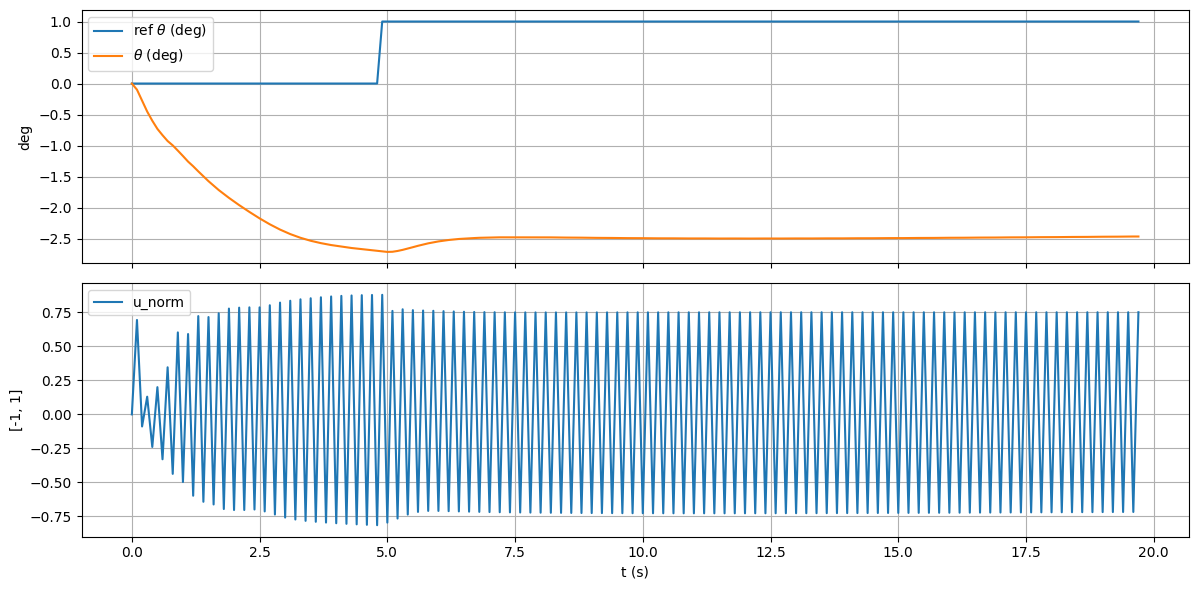

In [17]:
# Step-response evaluation (deterministic) + plot

EVAL_STEP_EPISODES = 3


def eval_step_episode(agent: SAC, env: ImprovedB747Env):
    obs, _info = env.reset()
    done = False
    total = 0.0
    steps = 0
    theta = []
    target = []
    u = []
    infos = []

    while not done:
        a = agent.select_action(obs, evaluate=True)
        obs, r, terminated, truncated, info = env.step(a)
        done = bool(terminated or truncated)
        total += float(r)
        steps += 1
        infos.append(info)
        theta.append(float(info.get("theta_rad", 0.0)))
        target.append(float(info.get("target_theta_rad", 0.0)))
        u.append(float(info.get("u_norm", 0.0)))

    err_deg = np.rad2deg(np.asarray(theta) - np.asarray(target))
    rmse_deg = float(np.sqrt(np.mean(err_deg**2))) if len(err_deg) else float('nan')
    final_err_deg = float(err_deg[-1]) if len(err_deg) else float('nan')
    max_abs_err_deg = float(np.max(np.abs(err_deg))) if len(err_deg) else float('nan')
    max_overshoot = float(max(i.get("overshoot_ratio", 0.0) for i in infos)) if infos else 0.0
    settled = bool(any(i.get("settled", False) for i in infos))
    settle_time_s = -1.0
    for i in infos:
        if bool(i.get("settled", False)):
            settle_time_s = float(i.get("settle_time_s", -1.0))

    return {
        "return": float(total),
        "steps": int(steps),
        "rmse_deg": rmse_deg,
        "final_err_deg": final_err_deg,
        "max_abs_err_deg": max_abs_err_deg,
        "max_overshoot_ratio": max_overshoot,
        "settled": settled,
        "settle_time_s": float(settle_time_s),
        "theta_rad": np.asarray(theta, dtype=np.float64),
        "target_rad": np.asarray(target, dtype=np.float64),
        "u_norm": np.asarray(u, dtype=np.float64),
    }


# Fresh eval env (step) — always evaluate on the fixed 1deg@5s target

ev = ImprovedB747Env(
    initial_state=INITIAL_STATE,
    reference_signal=STEP_EVAL_REFERENCE_SIGNAL,
    number_time_steps=200,
    dt=DT,
    reward_mode="step_response",
    initial_elevator_deg=0.0,
)
try:
    ev.unwrapped.model.discretisation_time = float(DT)
except Exception:
    pass

results = []
for ep in range(int(EVAL_STEP_EPISODES)):
    out = eval_step_episode(agent, ev)
    results.append(out)
    print(
        f"Step eval {ep+1}: return={out['return']:.3f}, rmse_deg={out['rmse_deg']:.4f}, "
        f"final_err_deg={out['final_err_deg']:.4f}, overshoot={out['max_overshoot_ratio']:.3f}, "
        f"settled={out['settled']}, settle_time_s={out['settle_time_s']}"
    )

# Plot last episode
last = results[-1]
t_sec = np.arange(len(last["theta_rad"])) * float(DT)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t_sec, np.rad2deg(last["target_rad"]), label=r"ref $\theta$ (deg)")
ax[0].plot(t_sec, np.rad2deg(last["theta_rad"]), label=r"$\theta$ (deg)")
ax[0].set_ylabel("deg")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(t_sec, last["u_norm"], label="u_norm")
ax[1].set_xlabel("t (s)")
ax[1].set_ylabel("[-1, 1]")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

